Using device: cuda
Epoch [1/10]  Train Acc: 0.9144 | Test Acc: 0.9636
Epoch [2/10]  Train Acc: 0.9654 | Test Acc: 0.9731
Epoch [3/10]  Train Acc: 0.9728 | Test Acc: 0.9755
Epoch [4/10]  Train Acc: 0.9778 | Test Acc: 0.9768
Epoch [5/10]  Train Acc: 0.9800 | Test Acc: 0.9757
Epoch [6/10]  Train Acc: 0.9837 | Test Acc: 0.9767
Epoch [7/10]  Train Acc: 0.9842 | Test Acc: 0.9808
Epoch [8/10]  Train Acc: 0.9861 | Test Acc: 0.9830
Epoch [9/10]  Train Acc: 0.9874 | Test Acc: 0.9821
Epoch [10/10]  Train Acc: 0.9886 | Test Acc: 0.9817


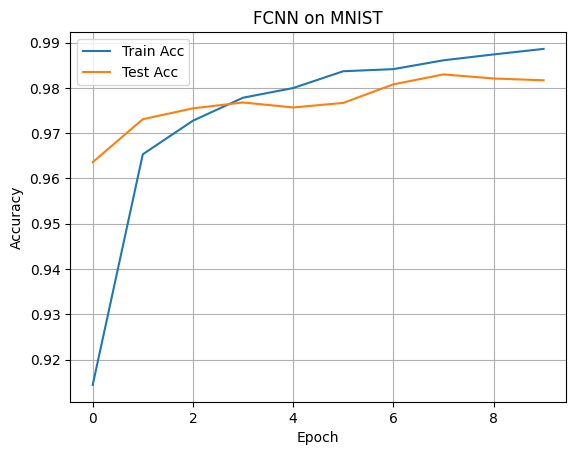

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# MNIST Dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# FCNN Model
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layers(x)

model = FCNN().to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
train_acc_list = []
test_acc_list = []

for epoch in range(1, 11):
    model.train()
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_acc_list.append(train_acc)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    test_acc_list.append(test_acc)

    print(f'Epoch [{epoch}/10]  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

# Accuracy Plot
plt.plot(train_acc_list, label='Train Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('FCNN on MNIST')
plt.grid(True)
plt.show()
